In [5]:
import tifffile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import pathlib
from scipy.ndimage import distance_transform_edt

import skimage
from skimage.feature import peak_local_max
from skimage import util,  restoration
from skimage.filters import threshold_otsu, threshold_isodata, threshold_li, threshold_minimum, threshold_mean, threshold_yen, threshold_multiotsu, threshold_triangle
from skimage.segmentation import clear_border, expand_labels, watershed
from skimage.measure import label, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, closing,  disk, dilation
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from skimage.filters import try_all_threshold
from skimage.filters import gaussian, median as median_filter, threshold_li, threshold_mean, threshold_triangle, threshold_yen
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import closing, disk, square, erosion, remove_small_holes
from skimage.segmentation import watershed, expand_labels
from skimage.feature import peak_local_max
import warnings
warnings.filterwarnings("ignore")
import pathlib
from skimage.morphology import closing,  disk, dilation, erosion, ball
from skimage.measure import regionprops
from skimage.exposure import rescale_intensity
import contextlib
import joblib
from tqdm import tqdm
from joblib import Parallel, delayed

In [18]:
test_image = tifffile.imread(r"Z:\Dorota_Avalon\cytokine array\cytokine array devices\c1\IM000252.Tif")

In [24]:
import skimage.measure as skm

labelled_devices_raw = label(test_image > threshold_triangle(test_image))

# Keep only the 4 largest regions, reindex 1-4 L->R, T->B
props_all = skm.regionprops(labelled_devices_raw)
top4 = sorted(props_all, key=lambda p: p.area, reverse=True)[:4]
top4_sorted = sorted(top4, key=lambda p: (p.centroid[0], p.centroid[1]))

label_map = np.zeros(labelled_devices_raw.max() + 1, dtype=labelled_devices_raw.dtype)
for new_label, prop in enumerate(top4_sorted, start=1):
    label_map[prop.label] = new_label
labelled_devices = label_map[labelled_devices_raw]


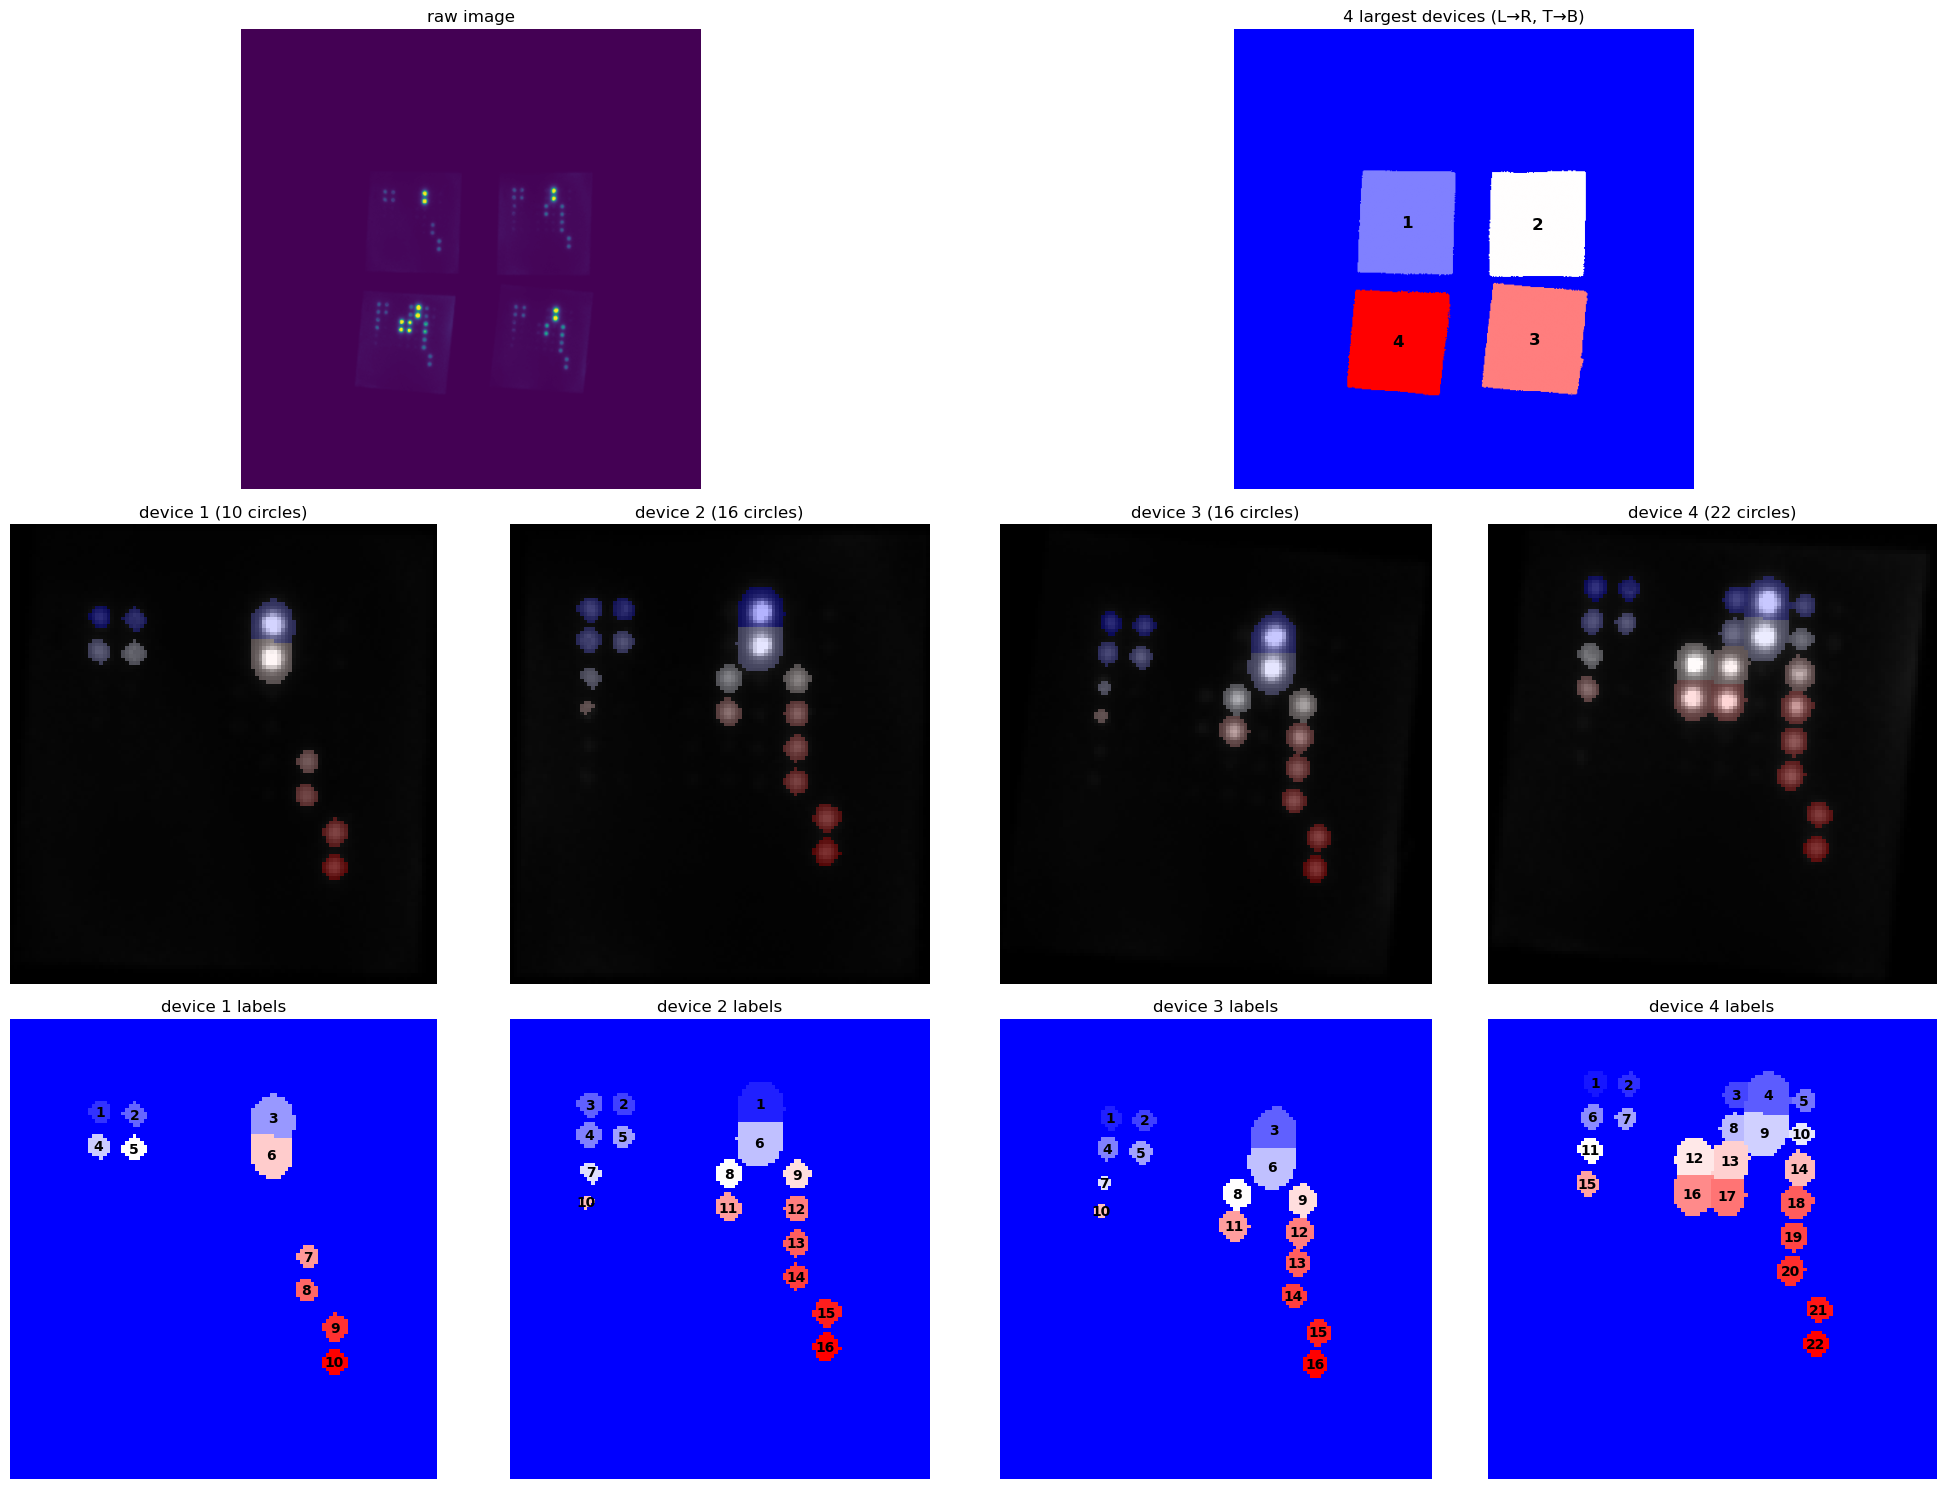

,device_id,circle_id,total_intensity
0,1,1,250100
1,1,2,207979
2,1,3,2610070
3,1,4,262057
4,1,5,228720
...,...,...,...
59,4,18,1041359
60,4,19,551000
61,4,20,551770
62,4,21,396851


In [33]:
import matplotlib.gridspec as gridspec

def segment_circles(crop):
    """Threshold + watershed circles within a device crop. Returns label image ordered L->R, T->B."""
    rescaled = rescale_intensity(crop.astype(float), out_range=(0, 255))
    circles = rescaled > threshold_li(rescaled)
    labelled = label(circles)
    coords = peak_local_max(rescaled, min_distance=4)
    markers = np.zeros(rescaled.shape, dtype=np.uint32)
    markers[tuple(np.round(coords).astype(int).T)] = np.arange(len(coords)) + 1
    seg = expand_labels(watershed(-rescaled, markers, mask=labelled > 0), distance=1)

    sorted_props = sorted(skm.regionprops(seg), key=lambda p: (p.centroid[0], p.centroid[1]))
    lmap = np.zeros(seg.max() + 1, dtype=seg.dtype)
    for new_id, p in enumerate(sorted_props, start=1):
        lmap[p.label] = new_id
    return lmap[seg], rescaled


device_ids = [d for d in sorted(np.unique(labelled_devices)) if d != 0]
n = len(device_ids)

# 3-row figure: top row spans all columns (split in two), then overlay row, then labels-only row
fig = plt.figure(figsize=(5 * n, 15))
gs = gridspec.GridSpec(3, n, figure=fig, height_ratios=[1, 1, 1])

# --- Top row: raw image and 4-largest-devices image ---
ax_raw = fig.add_subplot(gs[0, : n // 2])
ax_raw.imshow(test_image)
ax_raw.set_title("raw image")
ax_raw.axis("off")

ax_dev = fig.add_subplot(gs[0, n // 2 :])
ax_dev.imshow(labelled_devices, cmap="bwr")
for prop in skm.regionprops(labelled_devices):
    cy, cx = prop.centroid
    ax_dev.text(cx, cy, str(prop.label), color="black", fontsize=12,
                ha="center", va="center", fontweight="bold")
ax_dev.set_title(f"{n} largest devices (L→R, T→B)")
ax_dev.axis("off")

records = []
for i, dev_id in enumerate(device_ids):
    minr, minc, maxr, maxc = skm.regionprops((labelled_devices == dev_id).astype(int))[0].bbox
    crop = test_image[minr:maxr, minc:maxc]
    seg_ordered, rescaled = segment_circles(crop)

    # Row 2: rescaled intensity with segmentation overlay (no labels)
    ax_overlay = fig.add_subplot(gs[1, i])
    ax_overlay.imshow(rescaled, cmap="gray")
    ax_overlay.imshow(np.ma.masked_where(seg_ordered == 0, seg_ordered),
                      cmap="bwr", alpha=0.3)
    ax_overlay.set_title(f"device {dev_id} ({seg_ordered.max()} circles)")
    ax_overlay.axis("off")

    # Row 3: labels only with circle IDs printed
    ax_lbl = fig.add_subplot(gs[2, i])
    ax_lbl.imshow((seg_ordered),
                  cmap="bwr")
    for p in skm.regionprops(seg_ordered):
        cy, cx = p.centroid
        ax_lbl.text(cx, cy, str(p.label), color="black", fontsize=10,
                    ha="center", va="center", fontweight="bold")
    ax_lbl.set_title(f"device {dev_id} labels")
    ax_lbl.axis("off")

    pt = regionprops_table(seg_ordered, intensity_image=crop,
                           properties=["label", "area", "mean_intensity"])
    df = pd.DataFrame(pt)
    df["device_id"] = dev_id
    df["circle_id"] = df["label"]
    df["total_intensity"] = (df["mean_intensity"] * df["area"]).astype(int)
    records.append(df[["device_id", "circle_id", "total_intensity"]])

plt.tight_layout()
plt.show()

df_circles = pd.concat(records, ignore_index=True)
df_circles
